In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import geopandas
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
import torch
from torch_geometric.data import Data
from torch_geometric.utils import to_undirected
from torch_geometric.utils import degree
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_auc_score, f1_score

PATH_TO_MAP = "./500_cities_health_data/cb_2018_us_county_20m/"


/opt/homebrew/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
#read in pesticide data
#note that this is already log-transformed from the initial data prep, as it was extremely right-skewed
#this could incode some biological assumptions about the effects of increasing amounts of pesticide. 
pest_data = pd.read_csv('./USGS_pesticide_data/usgs_pest_2002_pivot_log.csv', dtype={'FIPS': str})
pest_data_cols = pest_data.columns.tolist()
pest_data_cols.remove('FIPS')

#read in incidence data
incd_data = pd.read_csv('./cancer_incidence_data_2023/cleaned_state_cancer_incd_data.csv', dtype={'FIPS': str})


In [3]:
pest_data.head()

,FIPS,"2,4-D","2,4-DB",ACETOCHLOR,ALACHLOR,ATRAZINE,BENTAZONE,BIFENTHRIN,BROMOXYNIL,CARBARYL,...,PERMETHRIN,PICLORAM,PROPICONAZOLE,RIMSULFURON,SETHOXYDIM,TERBUFOS,THIFENSULFURON,TRICLOPYR,TRIFLURALIN,ZETA-CYPERMETHRIN
0,01001,5.917280,6.521652,4.585987,5.481888,6.335409,3.627004,1.791759,3.380995,6.869638,...,3.668677,3.258097,3.194583,0.262364,4.473922,5.242276,0.587787,4.446174,5.899349,3.666122
1,01003,7.550819,8.419602,5.447599,6.834647,8.706623,4.976044,3.526361,5.529429,6.361648,...,4.789989,3.520461,5.296315,0.405465,5.071417,7.036676,2.879198,7.496819,7.386595,5.129899
2,01005,6.510853,7.303035,4.739701,5.022564,6.727312,4.690430,2.066863,3.686376,5.266827,...,2.791165,3.517498,6.233234,0.182322,3.100092,6.186209,0.530628,6.286557,7.307068,2.484907
3,01007,6.234215,5.393173,2.360854,3.597312,5.939645,NaN,NaN,NaN,2.694627,...,0.875469,3.081910,0.741937,0.095310,0.262364,1.193922,NaN,4.464758,0.262364,0.182322
4,01009,8.873846,5.442418,4.446174,5.340419,6.612041,4.533674,NaN,2.572612,5.027820,...,4.456670,6.939157,3.511545,0.182322,3.299534,3.218876,0.262364,4.432007,5.229503,2.091864


In [4]:
incd_data.head()

,County,FIPS,Rural_Urban_Code,Age_Adjusted_Incd_Rate,Lower 95% Confidence Interval,Upper 95% Confidence Interval,Average Annual Count,Recent Trend,Recent 5-Year Trend ([trend note]) in Incidence Rates,Lower 95% Confidence Interval.1,Upper 95% Confidence Interval.1
0,"Union County, Florida(2)",12125,Rural,1215.0,1144.9,1288.5,237,stable,0.3,-0.6,1.2
1,"Polk County, Texas(7)",48373,Rural,683.8,651.9,716.9,440,stable,-1.7,-3.9,0.8
2,"McPherson County, Nebraska(2)",31117,Rural,677.0,377.1,1145.8,4,*,*,*,*
3,"Dewey County, South Dakota(2)",46041,Rural,649.8,543.8,769.7,29,stable,1.4,-0.5,3.4
4,"Bracken County, Kentucky(7)",21023,Urban,621.8,555,695,68,stable,0.7,-0.6,2.1


In [5]:
#join the Age_Adjusted_Incd_Rate to the pest_data on FIPS
merged_data = pd.merge(pest_data, incd_data[['FIPS', 'Age_Adjusted_Incd_Rate', 'Recent Trend', 'County']], on='FIPS', how='left')


In [6]:
#what pesticides are most correlated with Age_Adjusted_Incd_Rate
correlation_matrix = merged_data.corr(numeric_only=True)
pest_correlation = correlation_matrix['Age_Adjusted_Incd_Rate'].sort_values(ascending=False)
pest_correlation

Age_Adjusted_Incd_Rate    1.000000
ATRAZINE                  0.118536
CARBARYL                  0.099804
IMAZETHAPYR               0.098361
METOLACHLOR-S             0.091573
GLYPHOSATE                0.075132
BIFENTHRIN                0.064599
DIMETHENAMID              0.059040
ACETOCHLOR                0.058861
PENDIMETHALIN             0.047249
NICOSULFURON              0.043679
PARAQUAT                  0.025875
ALACHLOR                  0.020427
RIMSULFURON               0.018099
PERMETHRIN                0.016186
CHLORPYRIFOS              0.011610
BENTAZONE                 0.008517
CLETHODIM                 0.003285
CYFLUTHRIN               -0.007266
SETHOXYDIM               -0.010888
ZETA-CYPERMETHRIN        -0.015920
CARBOFURAN               -0.016948
PROPICONAZOLE            -0.024179
CYHALOTHRIN-LAMBDA       -0.032129
METRIBUZIN               -0.033760
TERBUFOS                 -0.038723
THIFENSULFURON           -0.045408
TRICLOPYR                -0.053531
2,4-D               

In [7]:
#read in specific cancer-type incidence data
bladder_incd = pd.read_csv('cancer_incidence_data_2023/bladder_incd_2018_2022.csv')
breast_incd = pd.read_csv('cancer_incidence_data_2023/breast_incd.csv')
colorectal_incd = pd.read_csv('cancer_incidence_data_2023/colorectal_incd.csv')
lung_incd = pd.read_csv('cancer_incidence_data_2023/lung_incd.csv')
prostate_incd = pd.read_csv('cancer_incidence_data_2023/prostate_incd.csv')
leukemia_incd = pd.read_csv('cancer_incidence_data_2023/leukemia_incd.csv')
nhl_incd = pd.read_csv('cancer_incidence_data_2023/nhl_incd.csv')


In [8]:
nhl_incd.head(100)

,County,FIPS,2023 Rural-Urban Continuum Codes([rural urban note]),"Age-Adjusted Incidence Rate([rate note]) - cases per 100,000",Lower 95% Confidence Interval,Upper 95% Confidence Interval,CI*Rank([rank note]),Lower CI (CI*Rank),Upper CI (CI*Rank),Average Annual Count,Recent Trend,Recent 5-Year Trend ([trend note]) in Incidence Rates,Lower 95% Confidence Interval.1,Upper 95% Confidence Interval.1
0,US (SEER+NPCR)(1),0,NaN,15.4,15.3,15.5,N/A,N/A,N/A,33002,falling,-2.3,-2.8,-1.8
1,"Franklin County, Florida(2)",12037,Rural,38.6,19.5,69.9,N/A,N/A,N/A,3,*,*,*,*
2,"Wright County, Iowa(7)",19197,Rural,34.2,19.4,57.6,N/A,N/A,N/A,3,*,*,*,*
3,"Arenac County, Michigan(2)",26011,Rural,33.1,18.2,56.6,N/A,N/A,N/A,4,*,*,*,*
4,"Plymouth County, Iowa(7)",19149,Rural,31.3,20,46.9,N/A,N/A,N/A,5,*,*,*,*
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,"Cambria County, Pennsylvania(2)",42021,Urban,21.6,17.6,26.2,N/A,N/A,N/A,24,rising,1.9,0.2,3.8
96,"Kleberg County, Texas(7)",48273,Rural,21.5,12.3,35.1,N/A,N/A,N/A,3,*,*,*,*
97,"Mayes County, Oklahoma(2)",40097,Rural,21.5,14.3,31.5,N/A,N/A,N/A,6,stable,0.9,-3.3,5.4
98,"De Soto Parish, Louisiana(7)",22031,Urban,21.5,13.7,32.9,N/A,N/A,N/A,5,stable,-1.3,-7.2,2.3


In [9]:
#for each of these site-specific incd tables, we want a column in the original merged_data table, joining on FIPS, and only retaining the 'Age-Adjusted Incidence Rate([rate note]) - cases per 100,000' column, 
#with the col title like bladder_incd, breast_incd, etc.
bladder_incd = bladder_incd[['FIPS', 'Age-Adjusted Incidence Rate([rate note]) - cases per 100,000']].rename(columns={'Age-Adjusted Incidence Rate([rate note]) - cases per 100,000': 'bladder_incd'})
breast_incd = breast_incd[['FIPS', 'Age-Adjusted Incidence Rate([rate note]) - cases per 100,000']].rename(columns={'Age-Adjusted Incidence Rate([rate note]) - cases per 100,000': 'breast_incd'})
colorectal_incd = colorectal_incd[['FIPS', 'Age-Adjusted Incidence Rate([rate note]) - cases per 100,000']].rename(columns={'Age-Adjusted Incidence Rate([rate note]) - cases per 100,000': 'colorectal_incd'})
lung_incd = lung_incd[['FIPS', 'Age-Adjusted Incidence Rate([rate note]) - cases per 100,000']].rename(columns={'Age-Adjusted Incidence Rate([rate note]) - cases per 100,000': 'lung_incd'})
prostate_incd = prostate_incd[['FIPS', 'Age-Adjusted Incidence Rate([rate note]) - cases per 100,000']].rename(columns={'Age-Adjusted Incidence Rate([rate note]) - cases per 100,000': 'prostate_incd'})
leukemia_incd = leukemia_incd[['FIPS', 'Age-Adjusted Incidence Rate([rate note]) - cases per 100,000']].rename(columns={'Age-Adjusted Incidence Rate([rate note]) - cases per 100,000': 'leukemia_incd'})
nhl_incd = nhl_incd[['FIPS', 'Age-Adjusted Incidence Rate([rate note]) - cases per 100,000']].rename(columns={'Age-Adjusted Incidence Rate([rate note]) - cases per 100,000': 'nhl_incd'})


In [10]:

#merge on FIPS, but keep FIPS a string so we have the leading zeros, etc
merged_data['FIPS'] = merged_data['FIPS'].astype(str)
bladder_incd['FIPS'] = bladder_incd['FIPS'].astype(str)
breast_incd['FIPS'] = breast_incd['FIPS'].astype(str)
colorectal_incd['FIPS'] = colorectal_incd['FIPS'].astype(str)
lung_incd['FIPS'] = lung_incd['FIPS'].astype(str)
prostate_incd['FIPS'] = prostate_incd['FIPS'].astype(str)
leukemia_incd['FIPS'] = leukemia_incd['FIPS'].astype(str)
nhl_incd['FIPS'] = nhl_incd['FIPS'].astype(str)
merged_data = merged_data.merge(bladder_incd, on='FIPS', how='left')
merged_data = merged_data.merge(breast_incd, on='FIPS', how='left')
merged_data = merged_data.merge(colorectal_incd, on='FIPS', how='left')
merged_data = merged_data.merge(lung_incd, on='FIPS', how='left')
merged_data = merged_data.merge(prostate_incd, on='FIPS', how='left')
merged_data = merged_data.merge(leukemia_incd, on='FIPS', how='left')
merged_data = merged_data.merge(nhl_incd, on='FIPS', how='left')


In [11]:
merged_data.head()

,FIPS,"2,4-D","2,4-DB",ACETOCHLOR,ALACHLOR,ATRAZINE,BENTAZONE,BIFENTHRIN,BROMOXYNIL,CARBARYL,...,Age_Adjusted_Incd_Rate,Recent Trend,County,bladder_incd,breast_incd,colorectal_incd,lung_incd,prostate_incd,leukemia_incd,nhl_incd
0,01001,5.917280,6.521652,4.585987,5.481888,6.335409,3.627004,1.791759,3.380995,6.869638,...,459.8,stable,"Autauga County, Alabama(2)",NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,01003,7.550819,8.419602,5.447599,6.834647,8.706623,4.976044,3.526361,5.529429,6.361648,...,443.9,stable,"Baldwin County, Alabama(2)",NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,01005,6.510853,7.303035,4.739701,5.022564,6.727312,4.690430,2.066863,3.686376,5.266827,...,448.3,stable,"Barbour County, Alabama(2)",NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,01007,6.234215,5.393173,2.360854,3.597312,5.939645,NaN,NaN,NaN,2.694627,...,429.4,falling,"Bibb County, Alabama(2)",NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,01009,8.873846,5.442418,4.446174,5.340419,6.612041,4.533674,NaN,2.572612,5.027820,...,421.1,stable,"Blount County, Alabama(2)",NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
#write out merged data
#merged_data.to_csv('./merged_data_temp.csv', index=False)

We have missing data to deal with: first, NaNs in the pesticide levels. 
To handle the pesticide data, the means could be imputed, but as this is geographic data, and pesticides are frequently applied in agriculture, there is likely geographic correlation. As such, the adjancent counties can be calculated with the County Adjacency List from the Census, and then the mean of the surrounding counties can be imputed. 
The specific site incidence rates have '*' to indicate that there were insufficient cases for a given area-sex-race combination to ensure stability, per the  https://statecancerprofiles.cancer.gov/ data key. Because of population variance, even a very low number of cases could constitute a high rate, so imputing these would potentially disrupt any signal.  
Because the cancer rates are not just missing, but specifically suppressed, imputing them could be problematic. To avoid corrupting the rates, individual missing values will need to be masked in the actual neural net training/testing per cancer type.

In [12]:
#convert each incd column to numeric, coercing the errors to NaN, which will standardize all the missing/otherwise not preset data to NaN for easier masking later
merged_data['bladder_incd'] = pd.to_numeric(merged_data['bladder_incd'], errors='coerce')
merged_data['lung_incd'] = pd.to_numeric(merged_data['lung_incd'], errors='coerce')
merged_data['prostate_incd'] = pd.to_numeric(merged_data['prostate_incd'], errors='coerce')
merged_data['breast_incd'] = pd.to_numeric(merged_data['breast_incd'], errors='coerce')
merged_data['colorectal_incd'] = pd.to_numeric(merged_data['colorectal_incd'], errors='coerce')
merged_data['nhl_incd'] = pd.to_numeric(merged_data['nhl_incd'], errors='coerce')
merged_data['leukemia_incd'] = pd.to_numeric(merged_data['leukemia_incd'], errors='coerce')

In [13]:
merged_data.head()

,FIPS,"2,4-D","2,4-DB",ACETOCHLOR,ALACHLOR,ATRAZINE,BENTAZONE,BIFENTHRIN,BROMOXYNIL,CARBARYL,...,Age_Adjusted_Incd_Rate,Recent Trend,County,bladder_incd,breast_incd,colorectal_incd,lung_incd,prostate_incd,leukemia_incd,nhl_incd
0,01001,5.917280,6.521652,4.585987,5.481888,6.335409,3.627004,1.791759,3.380995,6.869638,...,459.8,stable,"Autauga County, Alabama(2)",NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,01003,7.550819,8.419602,5.447599,6.834647,8.706623,4.976044,3.526361,5.529429,6.361648,...,443.9,stable,"Baldwin County, Alabama(2)",NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,01005,6.510853,7.303035,4.739701,5.022564,6.727312,4.690430,2.066863,3.686376,5.266827,...,448.3,stable,"Barbour County, Alabama(2)",NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,01007,6.234215,5.393173,2.360854,3.597312,5.939645,NaN,NaN,NaN,2.694627,...,429.4,falling,"Bibb County, Alabama(2)",NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,01009,8.873846,5.442418,4.446174,5.340419,6.612041,4.533674,NaN,2.572612,5.027820,...,421.1,stable,"Blount County, Alabama(2)",NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
#okay, now we can load up the county adjancency data so we can prepare to impute the geographically relevant data
county_adj = pd.read_csv('county_adjacency2025.txt', dtype=str, sep='|')
county_adj.head()


,County Name,County GEOID,Neighbor Name,Neighbor GEOID,Length
0,"Autauga County, AL",01001,"Chilton County, AL",01021,52283
1,"Autauga County, AL",01001,"Dallas County, AL",01047,51498
2,"Autauga County, AL",01001,"Elmore County, AL",01051,32991
3,"Autauga County, AL",01001,"Lowndes County, AL",01085,59160
4,"Autauga County, AL",01001,"Montgomery County, AL",01101,14548


In [15]:
#rename cols, drop NAs, and convert Length to int so it can be used as a weight for the imputation calculation
county_adj.rename(columns={'County GEOID': 'FIPS', 'Neighbor GEOID': 'Neighbor_FIPS'}, inplace=True)
print(county_adj.shape)
print(county_adj.isna().sum())
county_adj.dropna(inplace=True)
print(county_adj.shape)
print(county_adj.isna().sum())
county_adj['Length'] = county_adj['Length'].astype(int)
county_adj.head()


(18968, 5)
County Name       0
FIPS              0
Neighbor Name    10
Neighbor_FIPS    10
Length           10
dtype: int64
(18958, 5)
County Name      0
FIPS             0
Neighbor Name    0
Neighbor_FIPS    0
Length           0
dtype: int64


,County Name,FIPS,Neighbor Name,Neighbor_FIPS,Length
0,"Autauga County, AL",01001,"Chilton County, AL",01021,52283
1,"Autauga County, AL",01001,"Dallas County, AL",01047,51498
2,"Autauga County, AL",01001,"Elmore County, AL",01051,32991
3,"Autauga County, AL",01001,"Lowndes County, AL",01085,59160
4,"Autauga County, AL",01001,"Montgomery County, AL",01101,14548


In [16]:

#to impute, need to set an immutable copy to be referenced while imputing, otherwise we'd start imputing based on other imputed values, and propagate any errors
source = merged_data.set_index('FIPS')
still_missing = []
source.head()

,"2,4-D","2,4-DB",ACETOCHLOR,ALACHLOR,ATRAZINE,BENTAZONE,BIFENTHRIN,BROMOXYNIL,CARBARYL,CARBOFURAN,...,Age_Adjusted_Incd_Rate,Recent Trend,County,bladder_incd,breast_incd,colorectal_incd,lung_incd,prostate_incd,leukemia_incd,nhl_incd
FIPS,,,,,,,,,,,,,,,,,,,,,
01001,5.917280,6.521652,4.585987,5.481888,6.335409,3.627004,1.791759,3.380995,6.869638,4.133565,...,459.8,stable,"Autauga County, Alabama(2)",NaN,NaN,NaN,NaN,NaN,NaN,NaN
01003,7.550819,8.419602,5.447599,6.834647,8.706623,4.976044,3.526361,5.529429,6.361648,5.719656,...,443.9,stable,"Baldwin County, Alabama(2)",NaN,NaN,NaN,NaN,NaN,NaN,NaN
01005,6.510853,7.303035,4.739701,5.022564,6.727312,4.690430,2.066863,3.686376,5.266827,4.737075,...,448.3,stable,"Barbour County, Alabama(2)",NaN,NaN,NaN,NaN,NaN,NaN,NaN
01007,6.234215,5.393173,2.360854,3.597312,5.939645,NaN,NaN,NaN,2.694627,2.219203,...,429.4,falling,"Bibb County, Alabama(2)",NaN,NaN,NaN,NaN,NaN,NaN,NaN
01009,8.873846,5.442418,4.446174,5.340419,6.612041,4.533674,NaN,2.572612,5.027820,5.155601,...,421.1,stable,"Blount County, Alabama(2)",NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [17]:
print(county_adj['Length'].describe())
print((county_adj['Length'] == 0).sum(), "zero-length borders")
print(county_adj['Length'].isna().sum(), "null lengths")

count     18958.000000
mean      38422.688891
std       36493.998379
min           0.000000
25%       18106.250000
50%       32400.000000
75%       48303.000000
max      657622.000000
Name: Length, dtype: float64
700 zero-length borders
0 null lengths


In [18]:

#the list of the pesticide cols was created immediately on reading in the data previously- 
#now we iterate through each pesticide column, and fill in missing values based on neighboring counties
#using the Length of the border as a weight
for col in pest_data_cols:
    src_col = source[col]
    #for each entry in the column                        
    for idx, row in merged_data.iterrows():

        #if its a missing value 
        if pd.isna(row[col]):
            fips = row['FIPS']
            #select all the neighboring counties for this FIPS
            neighbors = county_adj[county_adj['FIPS'] == fips]

            #get the values and weights for each neighboring county that has a value
            neighbor_values = []
            neighbor_weights = []
            #loop through each neighboring county to collect values and weights
            for _, n_row in neighbors.iterrows():
                nb_fips = n_row['Neighbor_FIPS']
                if nb_fips in src_col.index:
                    val = src_col.loc[nb_fips]
                    if pd.notna(val):
                        neighbor_values.append(val)
                        neighbor_weights.append(n_row['Length'])
            #if we found any neighbors with values, compute the weighted average or fall back to unweighted avg
            if neighbor_values:
                weight_sum = np.nansum(neighbor_weights)
                #sum the weights for the neighbors
                if weight_sum > 0:
                    merged_data.at[idx, col] = np.average(
                        neighbor_values, weights=neighbor_weights)
                else:
                    # all neighbors zero/invalid length -> unweighted mean
                    merged_data.at[idx, col] = np.mean(neighbor_values)
            else:
                still_missing.append((fips, col))

# fallback for counties with no usable neighbors (islands, all-NaN neighborhoods)
for fips, col in still_missing:
    merged_data.loc[merged_data['FIPS'] == fips, col] = source[col].mean()
merged_data.head()
    

,FIPS,"2,4-D","2,4-DB",ACETOCHLOR,ALACHLOR,ATRAZINE,BENTAZONE,BIFENTHRIN,BROMOXYNIL,CARBARYL,...,Age_Adjusted_Incd_Rate,Recent Trend,County,bladder_incd,breast_incd,colorectal_incd,lung_incd,prostate_incd,leukemia_incd,nhl_incd
0,01001,5.917280,6.521652,4.585987,5.481888,6.335409,3.627004,1.791759,3.380995,6.869638,...,459.8,stable,"Autauga County, Alabama(2)",NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,01003,7.550819,8.419602,5.447599,6.834647,8.706623,4.976044,3.526361,5.529429,6.361648,...,443.9,stable,"Baldwin County, Alabama(2)",NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,01005,6.510853,7.303035,4.739701,5.022564,6.727312,4.690430,2.066863,3.686376,5.266827,...,448.3,stable,"Barbour County, Alabama(2)",NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,01007,6.234215,5.393173,2.360854,3.597312,5.939645,2.735283,1.417102,2.496017,2.694627,...,429.4,falling,"Bibb County, Alabama(2)",NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,01009,8.873846,5.442418,4.446174,5.340419,6.612041,4.533674,2.845787,2.572612,5.027820,...,421.1,stable,"Blount County, Alabama(2)",NaN,NaN,NaN,NaN,NaN,NaN,NaN


Excellent, now the pesticide values are computed, and there's a uniform sentinel value for missing data per cancer type. 


In [19]:
#scale the pesticide columns so that they are on a comparable scale for modeling
scaler = StandardScaler()
merged_data[pest_data_cols] = scaler.fit_transform(merged_data[pest_data_cols])
merged_data.head()


,FIPS,"2,4-D","2,4-DB",ACETOCHLOR,ALACHLOR,ATRAZINE,BENTAZONE,BIFENTHRIN,BROMOXYNIL,CARBARYL,...,Age_Adjusted_Incd_Rate,Recent Trend,County,bladder_incd,breast_incd,colorectal_incd,lung_incd,prostate_incd,leukemia_incd,nhl_incd
0,01001,-0.939669,1.195228,-0.651912,-0.179933,-0.499193,-0.088337,-0.517370,-0.323026,1.165524,...,459.8,stable,"Autauga County, Alabama(2)",NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,01003,0.012439,2.246521,-0.302516,0.434014,0.470885,0.521239,0.520084,0.662926,0.912330,...,443.9,stable,"Baldwin County, Alabama(2)",NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,01005,-0.593705,1.628044,-0.589578,-0.388397,-0.338863,0.392182,-0.352833,-0.182881,0.366646,...,448.3,stable,"Barbour County, Alabama(2)",NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,01007,-0.754943,0.570153,-1.554235,-1.035244,-0.661103,-0.491269,-0.741451,-0.729156,-0.915397,...,429.4,falling,"Bibb County, Alabama(2)",NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,01009,0.783565,0.597431,-0.708608,-0.244139,-0.386021,0.321350,0.113037,-0.694005,0.247520,...,421.1,stable,"Blount County, Alabama(2)",NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [20]:
merged_data_backup = merged_data.copy()

In [129]:
merged_data = merged_data_backup

In [21]:
#time to read in some demographic and other covariate data. 
edu_data = pd.read_csv('USDA_economic_research_data/education_2000s_cleaned.csv', dtype={'FIPS Code': str})
emp_data = pd.read_csv('USDA_economic_research_data/unemployment_2000s_cleaned.csv', dtype={'FIPS_Code': str})

smoking_data = pd.read_csv('../../Downloads/places.csv', dtype={'LocationID': str})

/var/folders/q8/9bqx74355bg060d9qxv4bsf80000gn/T/ipykernel_76072/910525097.py:5: DtypeWarning: Columns (0: Data_Value_Footnote_Symbol, 1: Data_Value_Footnote) have mixed types. Specify dtype option on import or set low_memory=False.
  smoking_data = pd.read_csv('../../Downloads/places.csv', dtype={'LocationID': str})


In [22]:
#from the smoking dataset, we need to select only the relevant columns: Year, "LocationID" , "Data_Value", and "Measure"


#then we only keep the rows where the measure is "Current cigarette smoking among adults"
smoking_data = smoking_data[smoking_data['Measure'] == 'Current cigarette smoking among adults']
smoking_data = smoking_data[smoking_data['Data_Value_Type'] == 'Age-adjusted prevalence']
smoking_data = smoking_data[['Year', 'LocationID', 'Data_Value', 'Measure']]
#then rename LocationID to FIPS, and Data_Value to Smoking_Prevalence
smoking_data = smoking_data.rename(columns={'LocationID': 'FIPS', 'Data_Value': 'Smoking_Prevalence'})
smoking_data.shape


(2958, 4)

In [23]:
#how many unique FIPS in the smoking data
smoking_data['FIPS'].nunique()

2958

In [24]:
emp_data = emp_data[['FIPS_Code', 'Unemployment_rate_']]
emp_data = emp_data.rename(columns={'FIPS_Code': 'FIPS', 'Unemployment_rate_': 'Unemployment_Rate'})
emp_data.head()

,FIPS,Unemployment_Rate
0,01000,5.57
1,01001,4.74
2,01003,4.71
3,01005,7.51
4,01007,6.15


In [25]:
edu_data = edu_data[['FIPS Code', 'Percent of adults who are not high school graduates','Percent of adults with a bachelor\'s degree or higher' ]]
edu_data = edu_data.rename(columns={'FIPS Code': 'FIPS', 'Percent of adults who are not high school graduates': 'No_High_School', "Percent of adults with a bachelor's degree or higher": 'Bachelors_or_Higher'})
edu_data.head()

,FIPS,No_High_School,Bachelors_or_Higher
0,01000,24.7,19.0
1,01001,21.3,18.0
2,01003,18.0,23.1
3,01005,35.3,10.9
4,01007,36.8,7.1


In [26]:
#now these are ready to join
print(merged_data.shape)

merged_data = merged_data.merge(smoking_data, on='FIPS', how='left').merge(emp_data, on='FIPS', how='left').merge(edu_data, on='FIPS', how='left')
print(merged_data.shape)

(3052, 50)
(3052, 56)


In [27]:
#print FIPS counts- any duplicates in merged data?
print(merged_data['FIPS'].value_counts())
#if any FIPS has a count greater than 1, that means there are duplicates
print(merged_data['FIPS'].value_counts()[merged_data['FIPS'].value_counts() > 1])

FIPS
01001    1
01003    1
01005    1
01007    1
01009    1
        ..
56037    1
56039    1
56041    1
56043    1
56045    1
Name: count, Length: 3052, dtype: int64
Series([], Name: count, dtype: int64)


In [ ]:
#drop "Measure" column from the merged data as it is no longer needed
merged_data = merged_data.drop(columns=['Measure']) if 'Measure' in merged_data.columns else merged_data

In [29]:
#need to impute in the smoking data, edu data, and unemployment data. We'll just use a simple mean here, as there isn't necessarily as strong a geographic component as there is to pesticide application.

merged_data['Smoking_Prevalence'] = merged_data['Smoking_Prevalence'].fillna(merged_data['Smoking_Prevalence'].mean())
merged_data['Unemployment_Rate'] = merged_data['Unemployment_Rate'].fillna(merged_data['Unemployment_Rate'].mean())
merged_data['No_High_School'] = merged_data['No_High_School'].fillna(merged_data['No_High_School'].mean())
merged_data['Bachelors_or_Higher'] = merged_data['Bachelors_or_Higher'].fillna(merged_data['Bachelors_or_Higher'].mean())

merged_data.head()

,FIPS,"2,4-D","2,4-DB",ACETOCHLOR,ALACHLOR,ATRAZINE,BENTAZONE,BIFENTHRIN,BROMOXYNIL,CARBARYL,...,colorectal_incd,lung_incd,prostate_incd,leukemia_incd,nhl_incd,Year,Smoking_Prevalence,Unemployment_Rate,No_High_School,Bachelors_or_Higher
0,01001,-0.939669,1.195228,-0.651912,-0.179933,-0.499193,-0.088337,-0.517370,-0.323026,1.165524,...,NaN,NaN,NaN,NaN,NaN,2023.0,14.5,4.74,21.3,18.0
1,01003,0.012439,2.246521,-0.302516,0.434014,0.470885,0.521239,0.520084,0.662926,0.912330,...,NaN,NaN,NaN,NaN,NaN,2023.0,13.3,4.71,18.0,23.1
2,01005,-0.593705,1.628044,-0.589578,-0.388397,-0.338863,0.392182,-0.352833,-0.182881,0.366646,...,NaN,NaN,NaN,NaN,NaN,2023.0,20.8,7.51,35.3,10.9
3,01007,-0.754943,0.570153,-1.554235,-1.035244,-0.661103,-0.491269,-0.741451,-0.729156,-0.915397,...,NaN,NaN,NaN,NaN,NaN,2023.0,19.9,6.15,36.8,7.1
4,01009,0.783565,0.597431,-0.708608,-0.244139,-0.386021,0.321350,0.113037,-0.694005,0.247520,...,NaN,NaN,NaN,NaN,NaN,2023.0,16.9,4.53,29.6,9.6


In [30]:
merged_data = merged_data.drop(columns=['Year'])

In [31]:
#scale the Smoking_Prevalence, No_High_School, Bachelors_or_Higher, and Unemployment_Rate columns so that they are on a similar scale for modeling
scaler = StandardScaler()
merged_data[['Smoking_Prevalence', 'No_High_School', 'Bachelors_or_Higher', 'Unemployment_Rate']] = scaler.fit_transform(merged_data[['Smoking_Prevalence', 'No_High_School', 'Bachelors_or_Higher', 'Unemployment_Rate']])
merged_data.head()


,FIPS,"2,4-D","2,4-DB",ACETOCHLOR,ALACHLOR,ATRAZINE,BENTAZONE,BIFENTHRIN,BROMOXYNIL,CARBARYL,...,breast_incd,colorectal_incd,lung_incd,prostate_incd,leukemia_incd,nhl_incd,Smoking_Prevalence,Unemployment_Rate,No_High_School,Bachelors_or_Higher
0,01001,-0.939669,1.195228,-0.651912,-0.179933,-0.499193,-0.088337,-0.517370,-0.323026,1.165524,...,NaN,NaN,NaN,NaN,NaN,NaN,-0.562498,-0.544021,-0.155534,0.221834
1,01003,0.012439,2.246521,-0.302516,0.434014,0.470885,0.521239,0.520084,0.662926,0.912330,...,NaN,NaN,NaN,NaN,NaN,NaN,-0.923810,-0.560828,-0.533461,0.899290
2,01005,-0.593705,1.628044,-0.589578,-0.388397,-0.338863,0.392182,-0.352833,-0.182881,0.366646,...,NaN,NaN,NaN,NaN,NaN,NaN,1.334389,1.007800,1.447792,-0.721292
3,01007,-0.754943,0.570153,-1.554235,-1.035244,-0.661103,-0.491269,-0.741451,-0.729156,-0.915397,...,NaN,NaN,NaN,NaN,NaN,NaN,1.063405,0.245895,1.619577,-1.226063
4,01009,0.783565,0.597431,-0.708608,-0.244139,-0.386021,0.321350,0.113037,-0.694005,0.247520,...,NaN,NaN,NaN,NaN,NaN,NaN,0.160126,-0.661668,0.795010,-0.893977


Whew! Everything should be imputed, scaled, and merged together. TIme to double-check there are no NaNs in the feaatures:


In [32]:
#combine all the feature cols to one list for easy separation later
feature_cols = pest_data_cols + ['Smoking_Prevalence', 'No_High_School', 'Bachelors_or_Higher', 'Unemployment_Rate']
#double check no NaNs in feature matrix
assert merged_data[feature_cols].notnull().all().all()

In [33]:
assert merged_data[feature_cols].select_dtypes(exclude='number').empty, "non-numeric feature"
print(len(feature_cols), "features across", len(merged_data), "counties")

43 features across 3052 counties


In [81]:
#actually, we need to drop the "Age_Adjusted_Incd_Rate" column - it could cause data leakage
merged_data = merged_data.drop(columns=["Age_Adjusted_Incd_Rate"])

Now that the data is fully prepared, we can build the graph neural net with PyTorch. The first step is building the graph itself using the FIPS county adjacency data.

In [82]:
#first reset the data index in case it got messed up during all the joins and drops
merged_data = merged_data.reset_index(drop=True)
#then build an index- to FIPS mapping so we can translate between the graph and the data
fips_to_idx = {fips: i for i, fips in enumerate(merged_data['FIPS'])}
idx_to_fips = {i: fips for fips, i in fips_to_idx.items()}

In [83]:
#instantiate a torch tensor for all the feature data
x = torch.tensor(merged_data[feature_cols].to_numpy(dtype=float), dtype=torch.float)

#then we can use the adjancency list to build the graph edges
src, dst = [], []
for _, r in county_adj.iterrows():
    a, b = r['FIPS'], r['Neighbor_FIPS']
    if a in fips_to_idx and b in fips_to_idx:
        src.append(fips_to_idx[a]); dst.append(fips_to_idx[b])
edge_index = torch.tensor([src, dst], dtype=torch.long)

#make the edges undirected- the county data may be missing some edges, or be only one way; 
#we dont need directionality at all, so this makes the graph symmetric 
edge_index = to_undirected(edge_index)


data = Data(x=x, edge_index=edge_index)
#store the FIPS codes so we can map back from node indices to the original county identifiers
data.fips = merged_data['FIPS'].tolist() 
print(data)

Data(x=[3052, 43], edge_index=[2, 18088], fips=[3052])


In [85]:
#count the average number of borders per county from the adjancency data
county_adj.groupby('FIPS')['Neighbor_FIPS'].count().mean()

np.float64(5.8784496124031005)

In [86]:
#sanity checks on the structure: there are 3,244 counties in the US, and the
#calculation from the adjancency list above shows us there's roughly 5.88 border per county, so we'd expect
#the average degree in the graph to be similar (degree = edges per node)
#isolated nodes are probably islands like in hawaii

deg = degree(data.edge_index[0], num_nodes=data.num_nodes)
print("isolated nodes:", int((deg == 0).sum()))
print("avg degree:", round(float(deg.mean()), 2))

isolated nodes: 10
avg degree: 5.93


Now it gets tricky- to use the same graph for each of the cancer types, we need to mask the missing data in each individual type so we don't have NaNs in the response, but 
we can still use all the counties that are relevant to that type. 

In [87]:
#first we'll need a list of the response cols:
response_cols = ['breast_incd','colorectal_incd', 'lung_incd','nhl_incd', 'leukemia_incd', 'prostate_incd', 'bladder_incd']

#how many non-missing values do we have for each response?
merged_data[response_cols].notna().sum().sort_values(ascending=False)


prostate_incd      2475
breast_incd        2460
lung_incd          2286
bladder_incd       2004
colorectal_incd    1972
leukemia_incd      1322
nhl_incd           1256
dtype: int64

In [88]:
#assessing signal: let's run a correlation matrix on the specific cancer types with the pesticides, like I did before, but only for the relevant columns so we can see which pesticides might be associated with which cancer types.
correlation_matrix_2 = merged_data.corr(numeric_only=True)
print(f'Bladder top correlations: {correlation_matrix_2["bladder_incd"].sort_values(ascending=False)[:15]}')
print(f'Prostate top correlations: {correlation_matrix_2["prostate_incd"].sort_values(ascending=False)[:15]}')
print(f'Lung top correlations: {correlation_matrix_2["lung_incd"].sort_values(ascending=False)[:15]}')
print(f'Colorectal top correlations: {correlation_matrix_2["colorectal_incd"].sort_values(ascending=False)[:15]}')
print(f'Breast top correlations: {correlation_matrix_2["breast_incd"].sort_values(ascending=False)[:15]}')
print(f'NHL top correlations: {correlation_matrix_2["nhl_incd"].sort_values(ascending=False)[:15]}')
print(f'Leukemia top correlations: {correlation_matrix_2["leukemia_incd"].sort_values(ascending=False)[:15]}')


Bladder top correlations: bladder_incd       1.000000
leukemia_incd      0.240668
lung_incd          0.224882
nhl_incd           0.218202
breast_incd        0.156290
colorectal_incd    0.133723
NICOSULFURON       0.128749
prostate_incd      0.124808
IMAZETHAPYR        0.111296
PERMETHRIN         0.110707
ACETOCHLOR         0.103615
ATRAZINE           0.098473
BIFENTHRIN         0.093025
DIMETHENAMID       0.086776
RIMSULFURON        0.083937
Name: bladder_incd, dtype: float64
Prostate top correlations: prostate_incd          1.000000
breast_incd            0.302602
PROPICONAZOLE          0.202176
Bachelors_or_Higher    0.189090
leukemia_incd          0.178077
TRIFLURALIN            0.143016
ALACHLOR               0.137997
THIFENSULFURON         0.127840
bladder_incd           0.124808
GLYPHOSATE             0.120309
CARBARYL               0.117296
BENTAZONE              0.111983
BROMOXYNIL             0.109967
TERBUFOS               0.102170
CYHALOTHRIN-LAMBDA     0.099556
Name: prosta

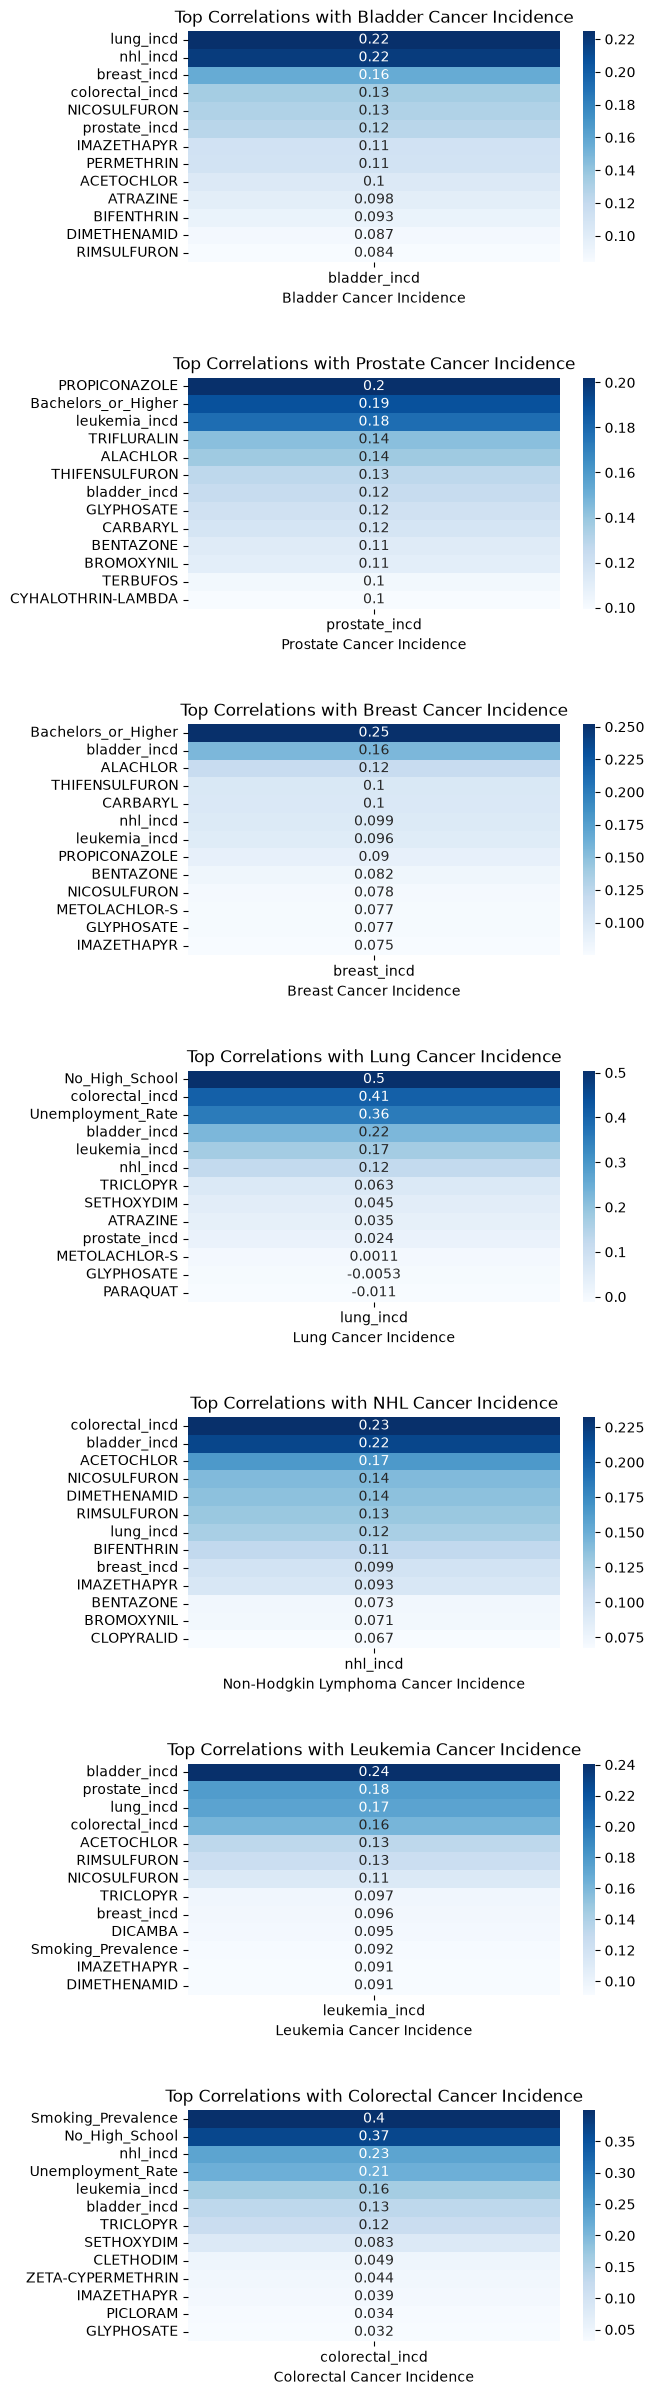

In [89]:
#heatmaps for the cancer correlations:
fig, ax = plt.subplots(7,1, figsize=(6,30))

ax[0] = sns.heatmap(pd.DataFrame(correlation_matrix_2["bladder_incd"].sort_values(ascending=False)[2:15]), annot=True, cmap="Blues", ax=ax[0])
ax[0].set_title("Top Correlations with Bladder Cancer Incidence")
ax[0].set_xlabel("Bladder Cancer Incidence")

ax[1] = sns.heatmap(pd.DataFrame(correlation_matrix_2["prostate_incd"].sort_values(ascending=False)[2:15]), annot=True, cmap="Blues", ax=ax[1])
ax[1].set_title("Top Correlations with Prostate Cancer Incidence")
ax[1].set_xlabel("Prostate Cancer Incidence")
ax[2] = sns.heatmap(pd.DataFrame(correlation_matrix_2["breast_incd"].sort_values(ascending=False)[2:15]), annot=True, cmap="Blues", ax=ax[2])
ax[2].set_title("Top Correlations with Breast Cancer Incidence")
ax[2].set_xlabel("Breast Cancer Incidence")
ax[3] = sns.heatmap(pd.DataFrame(correlation_matrix_2["lung_incd"].sort_values(ascending=False)[2:15]), annot=True, cmap="Blues", ax=ax[3])
ax[3].set_title("Top Correlations with Lung Cancer Incidence")
ax[3].set_xlabel("Lung Cancer Incidence")
ax[4] = sns.heatmap(pd.DataFrame(correlation_matrix_2["nhl_incd"].sort_values(ascending=False)[2:15]), annot=True, cmap="Blues", ax=ax[4])
ax[4].set_title("Top Correlations with NHL Cancer Incidence")
ax[4].set_xlabel("Non-Hodgkin Lymphoma Cancer Incidence")
ax[5] = sns.heatmap(pd.DataFrame(correlation_matrix_2["leukemia_incd"].sort_values(ascending=False)[2:15]), annot=True, cmap="Blues", ax=ax[5])
ax[5].set_title("Top Correlations with Leukemia Cancer Incidence")
ax[5].set_xlabel("Leukemia Cancer Incidence")
ax[6] = sns.heatmap(pd.DataFrame(correlation_matrix_2["colorectal_incd"].sort_values(ascending=False)[2:15]), annot=True, cmap="Blues", ax=ax[6])
ax[6].set_title("Top Correlations with Colorectal Cancer Incidence")
ax[6].set_xlabel("Colorectal Cancer Incidence")
fig.subplots_adjust(hspace=0.5)
plt.show()

Time to build and train the GNN:  
Some architecture decisions:  
-depth - how many layers ?  
-width - how many hidden units per layer ?  
-activation functions. 
-dropout or other regularization.   
-output layer: 1 logit for binary classification (per cancer type).   
-also regression (continuous output).   

sources for choosing number of layers, etc:   
https://medium.com/geekculture/introduction-to-neural-network-2f8b8221fbd3.   
https://medium.com/data-science/designing-your-neural-networks-a5e4617027ed   
https://milvus.io/ai-quick-reference/how-do-you-decide-the-number-of-neurons-per-layer.  

To build a classifier, we'll need to threshold to a binary target, we'll call it high or low cancer incidence.
  

Sources for building GNNs with PyTorch:  
https://www.geeksforgeeks.org/deep-learning/graph-neural-networks-with-pytorch/.   
https://github.com/pyg-team/pytorch_geometric/discussions/3405.   
https://dev.to/awadelrahman/tutorial-graph-neural-networks-for-social-networks-using-pytorch-2kf.    
https://pytorch-geometric.readthedocs.io/en/latest/index.html#.   
https://machinelearningmastery.com/a-gentle-introduction-to-graph-neural-networks-in-python/.   




In [ ]:
#following the standard pytorch pattern for setting up a neural net

class CancerIncdClassifier(torch.nn.Module):
    def __init__(self, in_dim, hidden=64, dropout=0.3):
        #this runs the parent class's initialization method
        super().__init__()
        #set up the layers
        self.conv1 = GCNConv(in_dim, hidden)
        self.conv2 = GCNConv(hidden, hidden)
        #head is a final linear layer  to give us the scalar output
        self.head = torch.nn.Linear(hidden,1)
        self.dropout = dropout

    #forward pass and activation 
    def forward(self, x, edge_index):
        #use ReLU for the first layer
        x = F.relu(self.conv1(x, edge_index))
        #regularlize
        x = F.dropout(x, p=self.dropout, training=self.training)
        #then relu for the second layer
        x = F.relu(self.conv2(x, edge_index))
        #regularize again
        x= F.dropout(x, p=self.dropout, training=self.training)
        #squeeze- pytorch built-in to make sure dimensions match
        return self.head(x).squeeze(-1)


#this function is where we convert from a more abstract "risk score" to high- or low-risk class based on 
#a threshold; this is chosen as either above or belowthe median (note: of the training set only to avoid data leakage)
def create_binary_threshold_target(col, train_mask):
    #ignore the NaNs
    vals = merged_data[col].to_numpy(dtype=float)
    #compute the median from only the training set, ignoring nans
    #using the median should be pretty balanced- could change to identify just anomalous values
    thresh = np.nanmedian(vals[train_mask.numpy()])
    #populate the tensor with the binary labels based on the threshold
    y = torch.tensor((vals > thresh).astype(float), dtype=torch.float)
    y[np.isnan(vals)] = float('nan') 
    return y, thresh
    
def train_classifier(model, data, y, train_mask, epochs=200, lr=0.01, weight_decay=5e-4):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    history = []
    #puts the model in Torch's training mode
    model.train()
    #loop for the desired epochs
    for epoch in range(epochs):
        #clears out the old gradients from the previuos pass
        optimizer.zero_grad()
        #forward pass to get the model's predictions
        logits = model(data.x, data.edge_index)
        #here the mask is used- we only compute loss and backpropagate on the nodes include as 'true' in the mask,
        #i.e. the counties that have labels (cancer rates) available 
        loss = F.binary_cross_entropy_with_logits(logits[train_mask], y[train_mask])
        #backpropagate the loss
        loss.backward()
        #update the model parameters based on the gradients using the optimizer
        optimizer.step()
        #record the loss for this epoch to track train loss progression 
        history.append(loss.item())
    return model, history

#this function evaluate sthe model, reporting accuracy, AUC, and f1. 
@torch.no_grad()
def evaluate_classifier(model, data, y, mask):
    #puts the model in evaluation mode so things like dropout are disabled
    model.eval()
    #forward pass to get the model's predictions
    logits= model(data.x, data.edge_index)
    #convert the logits to probabilities (mask to only the test data mask)
    probs = torch.sigmoid(logits[mask]).numpy()
    #prep the true labels from the mask as a numpy array for comparison with the predictions
    true = y[mask].numpy()
    preds = (probs > 0.5).astype(float)
    #then return the eval results, comparing the preds against the true labels. 
    return {
        "accuracy": (preds == true).mean(),
        "auc": roc_auc_score(true, probs),
        'f1': f1_score(true, preds)
    }


    

In [111]:
#collect model accuracy and auc scores for each cancer type
eval_dicts = []

## Train and Evaluate: Non-Hodgkins Lymphoma

In [ ]:
#create train and test sets and masks for nhl
nhl_present_idx = np.where(merged_data['nhl_incd'].notna().to_numpy())[0]

nhl_train_idx, nhl_test_idx = train_test_split(nhl_present_idx, test_size=0.2, random_state=42)

#get number of nodes from the county graph 
n = data.num_nodes

#here's how we build the masks: a boolean list with an entry corresponding to each node (county).
#Then each row index with data present is marked True in the mask, and then we can filter those later
#when it's time to compute the loss and backpropagate
nhl_train_mask = torch.zeros(n, dtype=torch.bool)
nhl_test_mask = torch.zeros(n, dtype=torch.bool)
nhl_train_mask[nhl_train_idx] = True
nhl_test_mask[nhl_test_idx] = True


In [149]:
print(f'Train indices: {nhl_train_idx[:10]}...')
print(f'Test indices: {nhl_test_idx[:10]}...')


Train indices: [1350  698 2490 2869 1201 1143 2103 3000 2839 2171]...
Test indices: [1278  472  350  382 2862 1264 2650 1746 2987 2570]...


{'accuracy': np.float64(0.6428571428571429), 'auc': 0.6869094937121263, 'f1': 0.5945945945945946}


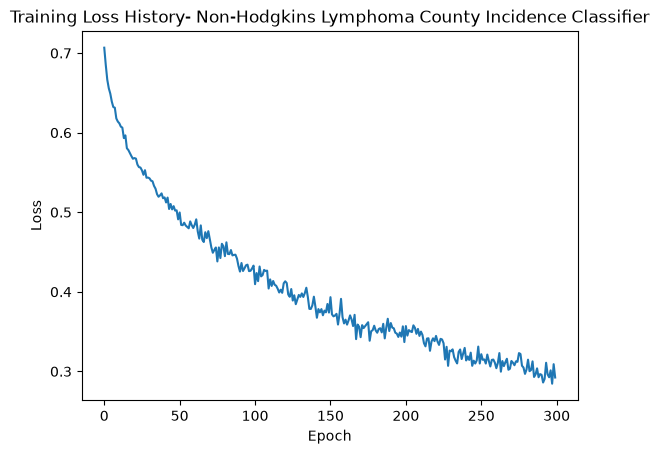

In [113]:
y_nhl, thresh = create_binary_threshold_target('nhl_incd', nhl_train_mask)
model = CancerIncdClassifier(in_dim=data.num_node_features)
model, history = train_classifier(model, data, y_nhl, nhl_train_mask, epochs=300)
nhl_eval_dict = evaluate_classifier(model, data, y_nhl, nhl_test_mask)
print(nhl_eval_dict)
eval_dicts.append(nhl_eval_dict)
plt.plot(history)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss History- Non-Hodgkins Lymphoma County Incidence Classifier")
plt.show()

In [129]:
print(y_nhl[600:610])

tensor([1., 1., 0., 1., 1., nan, 1., 1., 1., nan])


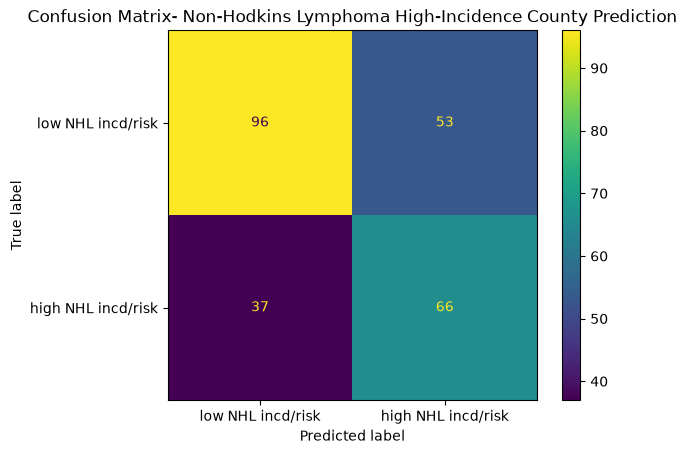

In [114]:
model.eval()
with torch.no_grad():
    logits = model(data.x, data.edge_index)
    probs = torch.sigmoid(logits[nhl_test_mask]).numpy()
    preds= (probs > 0.5).astype(int)
    true = y_nhl[nhl_test_mask].numpy()
        

conf_matrix = confusion_matrix(true, preds)
ConfusionMatrixDisplay(conf_matrix, display_labels=['low NHL incd/risk', 'high NHL incd/risk']).plot()
plt.title("Confusion Matrix- Non-Hodkins Lymphoma High-Incidence County Prediction")
plt.show()

## Train and Eval: Lung Cancer
We use the same code as above, but exchange the NHL rows for the lung rows to create the appropriate mask and then train. 

{'accuracy': np.float64(0.7510917030567685), 'auc': 0.8404959465903672, 'f1': 0.7420814479638009}


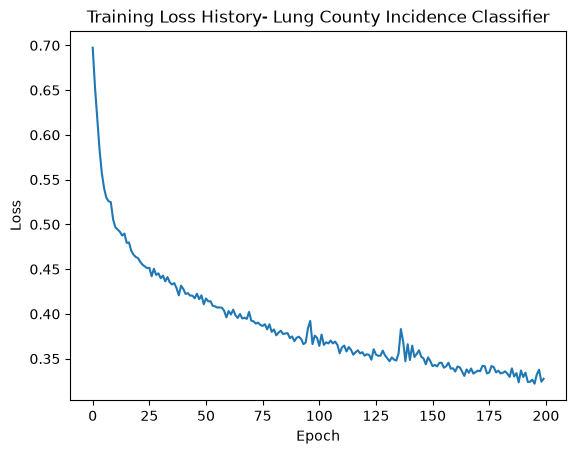

TypeError: CancerIncdClassifier.forward() missing 1 required positional argument: 'edge_index'

In [137]:
lung_present_idx = np.where(merged_data['lung_incd'].notna().to_numpy())[0]

lung_train_idx, lung_test_idx = train_test_split(lung_present_idx, test_size=0.2, random_state=42)
lung_train_mask = torch.zeros(n, dtype=torch.bool)
lung_test_mask = torch.zeros(n, dtype=torch.bool)
lung_train_mask[lung_train_idx] = True
lung_test_mask[lung_test_idx] = True

y_lung, thresh = create_binary_threshold_target('lung_incd', lung_train_mask)
model = CancerIncdClassifier(in_dim=data.num_node_features)
model, history= train_classifier(model, data, y_lung, lung_train_mask)
lung_eval_dict = evaluate_classifier(model, data, y_lung, lung_test_mask)
print(lung_eval_dict)
eval_dicts.append(lung_eval_dict)
plt.plot(history)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss History- Lung County Incidence Classifier")
plt.show()


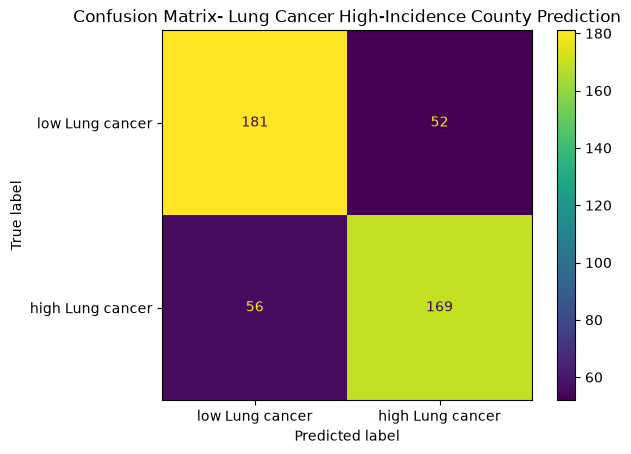

In [116]:
#confusion matrix for results

model.eval()
with torch.no_grad():
    logits = model(data.x, data.edge_index)
    probs = torch.sigmoid(logits[lung_test_mask]).numpy()
    preds= (probs > 0.5).astype(int)
    true = y_lung[lung_test_mask].numpy()
        

conf_matrix = confusion_matrix(true, preds)
ConfusionMatrixDisplay(conf_matrix, display_labels=['low Lung cancer', 'high Lung cancer']).plot()
plt.title("Confusion Matrix- Lung Cancer High-Incidence County Prediction")
plt.show()

# Train and Eval: Bladder CAncer

{'accuracy': np.float64(0.6982543640897756), 'auc': 0.7536937206748529, 'f1': 0.7125890736342043}


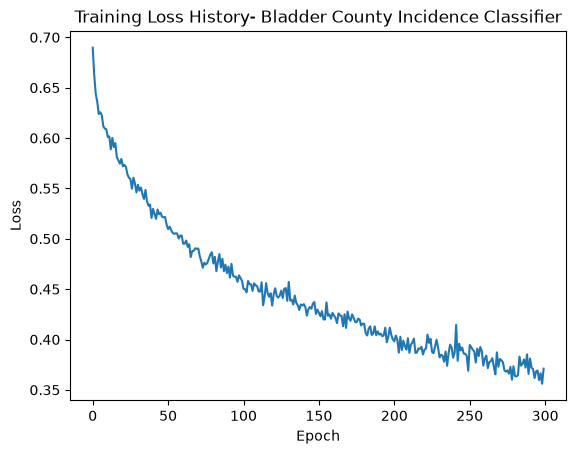

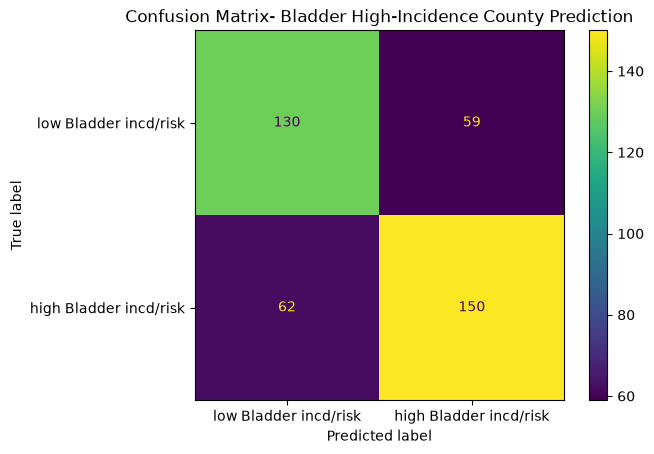

In [117]:
bladder_present_idx = np.where(merged_data['bladder_incd'].notna().to_numpy())[0]

bladder_train_idx, bladder_test_idx = train_test_split(bladder_present_idx, test_size=0.2, random_state=42)

#our graph from earlier is in 'data' - this is the number of nodes
n = data.num_nodes

bladder_train_mask = torch.zeros(n, dtype=torch.bool)
bladder_test_mask = torch.zeros(n, dtype=torch.bool)
bladder_train_mask[bladder_train_idx] = True
bladder_test_mask[bladder_test_idx] = True

y_bladder, thresh = create_binary_threshold_target('bladder_incd', bladder_train_mask)
model = CancerIncdClassifier(in_dim=data.num_node_features)
model, history = train_classifier(model, data, y_bladder, bladder_train_mask, epochs=300)
bladder_eval_dict = evaluate_classifier(model, data, y_bladder, bladder_test_mask)
print(bladder_eval_dict)
eval_dicts.append(bladder_eval_dict)

plt.plot(history)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss History- Bladder County Incidence Classifier")
plt.show()

model.eval()
with torch.no_grad():
    logits = model(data.x, data.edge_index)
    probs = torch.sigmoid(logits[bladder_test_mask]).numpy()
    preds= (probs > 0.5).astype(int)
    true = y_bladder[bladder_test_mask].numpy()
        

conf_matrix = confusion_matrix(true, preds)
ConfusionMatrixDisplay(conf_matrix, display_labels=['low Bladder incd/risk', 'high Bladder incd/risk']).plot()
plt.title("Confusion Matrix- Bladder High-Incidence County Prediction")
plt.show()

# TRain and Eval: Prostate Cancer

{'accuracy': np.float64(0.6868686868686869), 'auc': 0.7651023219205038, 'f1': 0.6790890269151139}


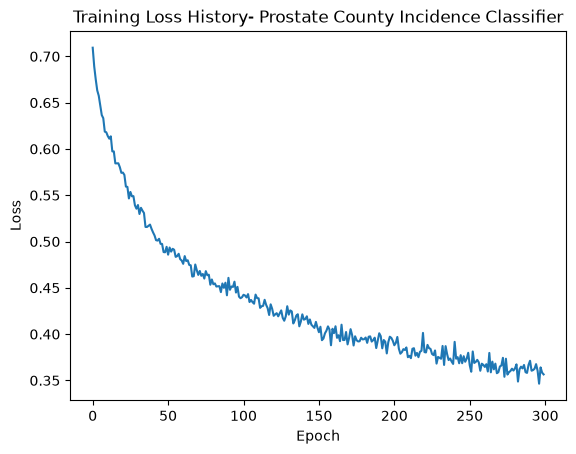

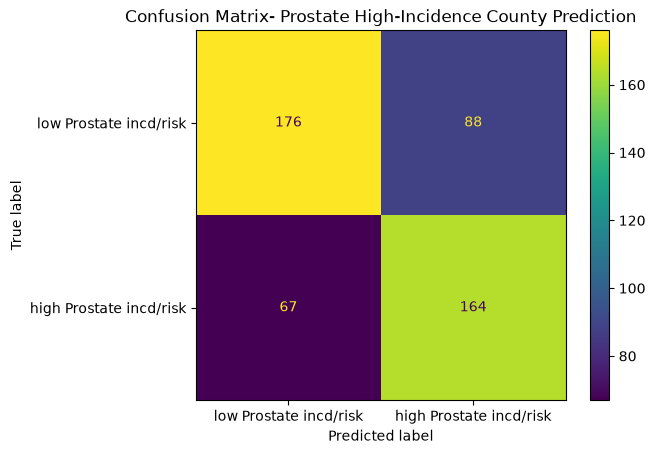

In [118]:
prostate_present_idx = np.where(merged_data['prostate_incd'].notna().to_numpy())[0]

prostate_train_idx, prostate_test_idx = train_test_split(prostate_present_idx, test_size=0.2, random_state=42)

#our graph from earlier is in 'data' - this is the number of nodes
n = data.num_nodes

prostate_train_mask = torch.zeros(n, dtype=torch.bool)
prostate_test_mask = torch.zeros(n, dtype=torch.bool)
prostate_train_mask[prostate_train_idx] = True
prostate_test_mask[prostate_test_idx] = True

y_prostate, thresh = create_binary_threshold_target('prostate_incd', prostate_train_mask)
model = CancerIncdClassifier(in_dim=data.num_node_features)
model, history = train_classifier(model, data, y_prostate, prostate_train_mask, epochs=300)
prostate_eval_dict = evaluate_classifier(model, data, y_prostate, prostate_test_mask)
print(prostate_eval_dict)
eval_dicts.append(prostate_eval_dict)
plt.plot(history)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss History- Prostate County Incidence Classifier")
plt.show()

model.eval()
with torch.no_grad():
    logits = model(data.x, data.edge_index)
    probs = torch.sigmoid(logits[prostate_test_mask]).numpy()
    preds= (probs > 0.5).astype(int)
    true = y_prostate[prostate_test_mask].numpy()
        

conf_matrix = confusion_matrix(true, preds)
ConfusionMatrixDisplay(conf_matrix, display_labels=['low Prostate incd/risk', 'high Prostate incd/risk']).plot()
plt.title("Confusion Matrix- Prostate High-Incidence County Prediction")
plt.show()

# Train and Eval: Leukemia

{'accuracy': np.float64(0.5773584905660377), 'auc': 0.6116954022988506, 'f1': 0.5912408759124088}


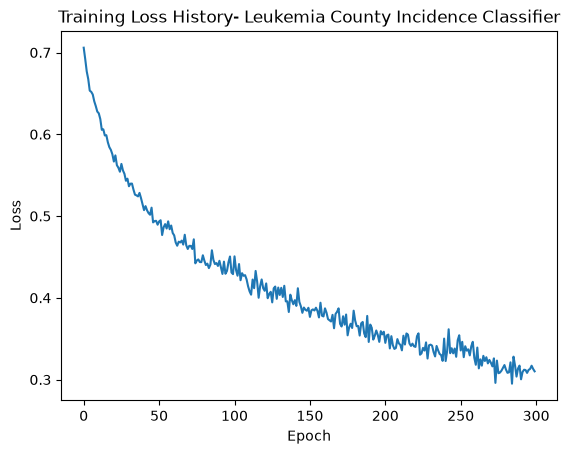

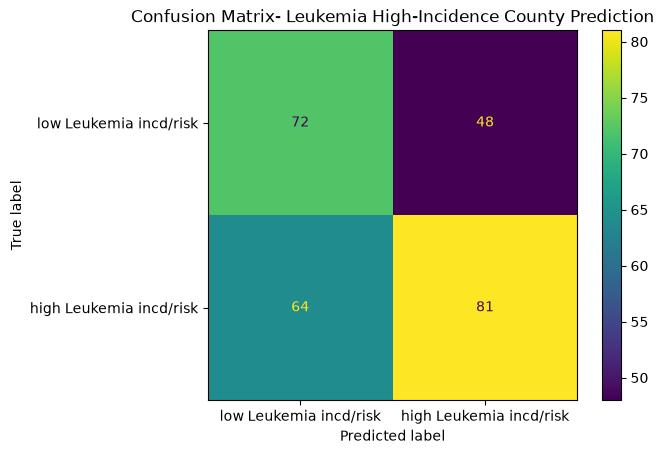

In [119]:
leukemia_present_idx = np.where(merged_data['leukemia_incd'].notna().to_numpy())[0]

leukemia_train_idx, leukemia_test_idx = train_test_split(leukemia_present_idx, test_size=0.2, random_state=42)

#our graph from earlier is in 'data' - this is the number of nodes
n = data.num_nodes

leukemia_train_mask = torch.zeros(n, dtype=torch.bool)
leukemia_test_mask = torch.zeros(n, dtype=torch.bool)
leukemia_train_mask[leukemia_train_idx] = True
leukemia_test_mask[leukemia_test_idx] = True

y_leukemia, thresh = create_binary_threshold_target('leukemia_incd', leukemia_train_mask)
model = CancerIncdClassifier(in_dim=data.num_node_features)
model, history = train_classifier(model, data, y_leukemia, leukemia_train_mask, epochs=300)
leukemia_eval_dict = evaluate_classifier(model, data, y_leukemia, leukemia_test_mask)
print(leukemia_eval_dict)
eval_dicts.append(leukemia_eval_dict)
plt.plot(history)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss History- Leukemia County Incidence Classifier")
plt.show()

model.eval()
with torch.no_grad():
    logits = model(data.x, data.edge_index)
    probs = torch.sigmoid(logits[leukemia_test_mask]).numpy()
    preds= (probs > 0.5).astype(int)
    true = y_leukemia[leukemia_test_mask].numpy()
        

conf_matrix = confusion_matrix(true, preds)
ConfusionMatrixDisplay(conf_matrix, display_labels=['low Leukemia incd/risk', 'high Leukemia incd/risk']).plot()
plt.title("Confusion Matrix- Leukemia High-Incidence County Prediction")
plt.show()

# Train and Eval : Colorectal

{'accuracy': np.float64(0.6506329113924051), 'auc': 0.7019028568497717, 'f1': 0.6461538461538462}


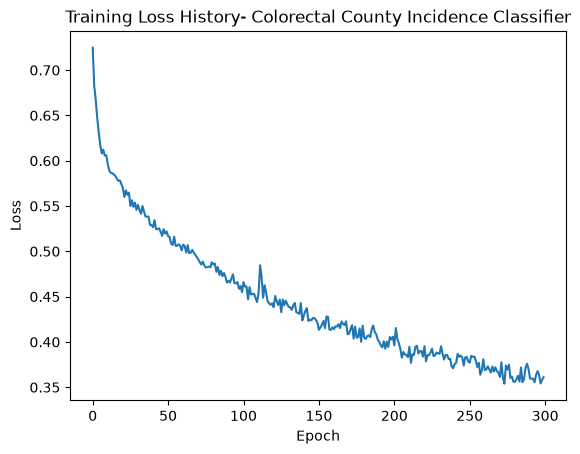

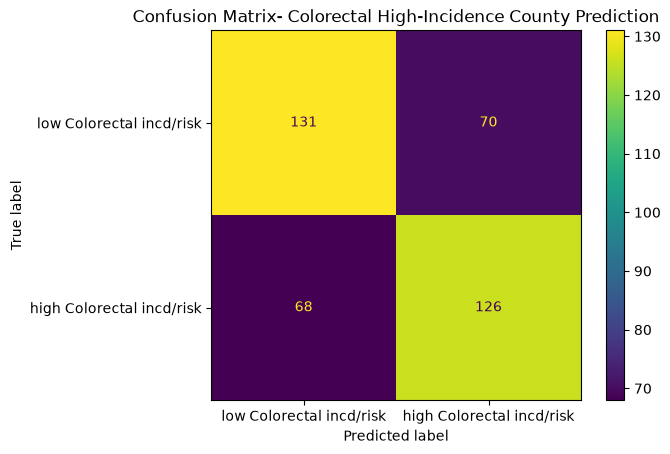

In [120]:
colorectal_present_idx = np.where(merged_data['colorectal_incd'].notna().to_numpy())[0]

colorectal_train_idx, colorectal_test_idx = train_test_split(colorectal_present_idx, test_size=0.2, random_state=42)

#our graph from earlier is in 'data' - this is the number of nodes
n = data.num_nodes

colorectal_train_mask = torch.zeros(n, dtype=torch.bool)
colorectal_test_mask = torch.zeros(n, dtype=torch.bool)
colorectal_train_mask[colorectal_train_idx] = True
colorectal_test_mask[colorectal_test_idx] = True

y_colorectal, thresh = create_binary_threshold_target('colorectal_incd', colorectal_train_mask)
model = CancerIncdClassifier(in_dim=data.num_node_features)
model, history = train_classifier(model, data, y_colorectal, colorectal_train_mask, epochs=300)
colorectal_eval_dict = evaluate_classifier(model, data, y_colorectal, colorectal_test_mask)
print(colorectal_eval_dict)
eval_dicts.append(colorectal_eval_dict)
plt.plot(history)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss History- Colorectal County Incidence Classifier")
plt.show()

model.eval()
with torch.no_grad():
    logits = model(data.x, data.edge_index)
    probs = torch.sigmoid(logits[colorectal_test_mask]).numpy()
    preds= (probs > 0.5).astype(int)
    true = y_colorectal[colorectal_test_mask].numpy()
        

conf_matrix = confusion_matrix(true, preds)
ConfusionMatrixDisplay(conf_matrix, display_labels=['low Colorectal incd/risk', 'high Colorectal incd/risk']).plot()
plt.title("Confusion Matrix- Colorectal High-Incidence County Prediction")
plt.show()

# Train and Eval : Breast Canccer

{'accuracy': np.float64(0.6321138211382114), 'auc': 0.6879616623977526, 'f1': 0.6056644880174292}


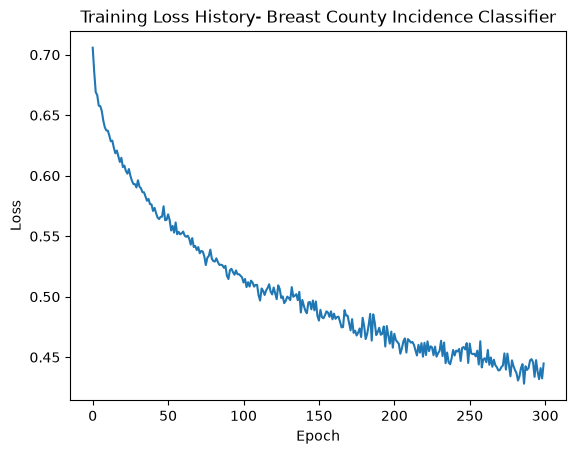

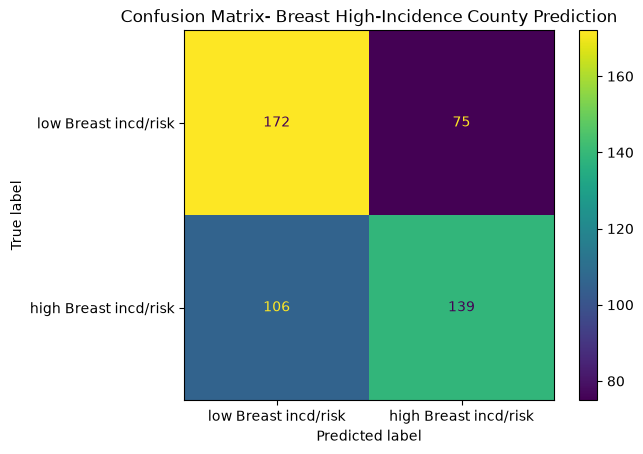

In [121]:
breast_present_idx = np.where(merged_data['breast_incd'].notna().to_numpy())[0]

breast_train_idx, breast_test_idx = train_test_split(breast_present_idx, test_size=0.2, random_state=42)

#our graph from earlier is in 'data' - this is the number of nodes
n = data.num_nodes

breast_train_mask = torch.zeros(n, dtype=torch.bool)
breast_test_mask = torch.zeros(n, dtype=torch.bool)
breast_train_mask[breast_train_idx] = True
breast_test_mask[breast_test_idx] = True

y_breast, thresh = create_binary_threshold_target('breast_incd', breast_train_mask)
model = CancerIncdClassifier(in_dim=data.num_node_features)
model, history = train_classifier(model, data, y_breast, breast_train_mask, epochs=300)
breast_eval_dict = evaluate_classifier(model, data, y_breast, breast_test_mask)
print(breast_eval_dict)
eval_dicts.append(breast_eval_dict)
plt.plot(history)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss History- Breast County Incidence Classifier")
plt.show()

model.eval()
with torch.no_grad():
    logits = model(data.x, data.edge_index)
    probs = torch.sigmoid(logits[breast_test_mask]).numpy()
    preds= (probs > 0.5).astype(int)
    true = y_breast[breast_test_mask].numpy()
        

conf_matrix = confusion_matrix(true, preds)
ConfusionMatrixDisplay(conf_matrix, display_labels=['low Breast incd/risk', 'high Breast incd/risk']).plot()
plt.title("Confusion Matrix- Breast High-Incidence County Prediction")
plt.show()

In [122]:
#print eval dicts to compare each cancer type accruacy
for eval_dict in eval_dicts:
    print(eval_dict)

{'accuracy': np.float64(0.6428571428571429), 'auc': 0.6869094937121263, 'f1': 0.5945945945945946}
{'accuracy': np.float64(0.7641921397379913), 'auc': 0.8373485932284216, 'f1': 0.757847533632287}
{'accuracy': np.float64(0.6982543640897756), 'auc': 0.7536937206748529, 'f1': 0.7125890736342043}
{'accuracy': np.float64(0.6868686868686869), 'auc': 0.7651023219205038, 'f1': 0.6790890269151139}
{'accuracy': np.float64(0.5773584905660377), 'auc': 0.6116954022988506, 'f1': 0.5912408759124088}
{'accuracy': np.float64(0.6506329113924051), 'auc': 0.7019028568497717, 'f1': 0.6461538461538462}
{'accuracy': np.float64(0.6321138211382114), 'auc': 0.6879616623977526, 'f1': 0.6056644880174292}


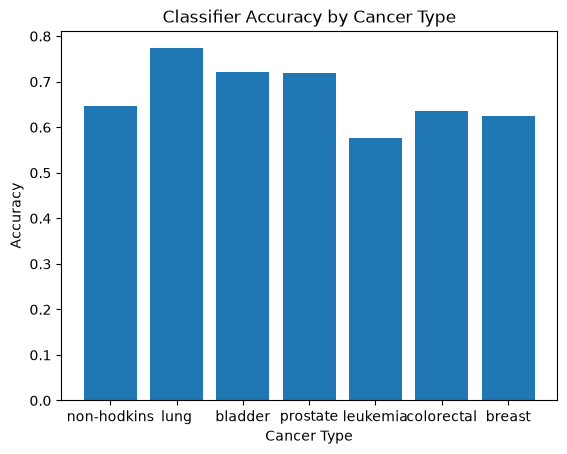

In [80]:
#plot accuracy for each cancer type
cancer_types = ['non-hodkins', 'lung', 'bladder', 'prostate', 'leukemia', 'colorectal', 'breast']
accuracies = [eval_dict['accuracy'] for eval_dict in eval_dicts]
plt.bar(cancer_types, accuracies)
plt.xlabel("Cancer Type")
plt.ylabel("Accuracy")
plt.title("Classifier Accuracy by Cancer Type")
plt.show()

# Interpretability

In [150]:
#ablate the pestiicide data to see how much it contributes to model performance
pest_cols = [c for c in feature_cols if c in pest_data_cols] 
conf_cols = [c for c in feature_cols if c not in pest_data_cols] 

#set up all features vs only the non-pesticide feaures
x_full = torch.tensor(merged_data[feature_cols].to_numpy(dtype=float), dtype=torch.float)
x_conf = torch.tensor(merged_data[conf_cols].to_numpy(dtype=float), dtype=torch.float)
#redo the graphs
data_full = Data(x=x_full, edge_index=data.edge_index)
data_conf = Data(x=x_conf, edge_index=data.edge_index)
#build the target vals
y_nhl_eval, _ = create_binary_threshold_target('nhl_incd', nhl_train_mask)

#train models on both sets
model_full = CancerIncdClassifier(in_dim=data_full.num_node_features)
train_classifier(model_full, data_full, y_nhl_eval, nhl_train_mask)
res_full = evaluate_classifier(model_full, data_full, y_nhl_eval, nhl_test_mask)
train_classifier(model_conf, data_conf, y_nhl_eval, nhl_train_mask)
res_conf = evaluate_classifier(model_conf, data_conf, y_nhl_eval, nhl_test_mask)
res_conf = evaluate_classifier(model_conf, data_conf, y_nhl_eval, nhl_test_mask)
print(f"With pesticides, AUC is {res_full['auc']:.3f}")
print(f"Confounders only, AUC is {res_conf['auc']:.3f}")
print(f"Pesticide contribution: {res_full['auc'] - res_conf['auc']:+.3f}")

With pesticides, AUC is 0.684
Confounders only, AUC is 0.650
Pesticide contribution: +0.034
